<a href="https://colab.research.google.com/github/Shwoouu/AAI2025/blob/dev/Coding_Exercise_Part_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

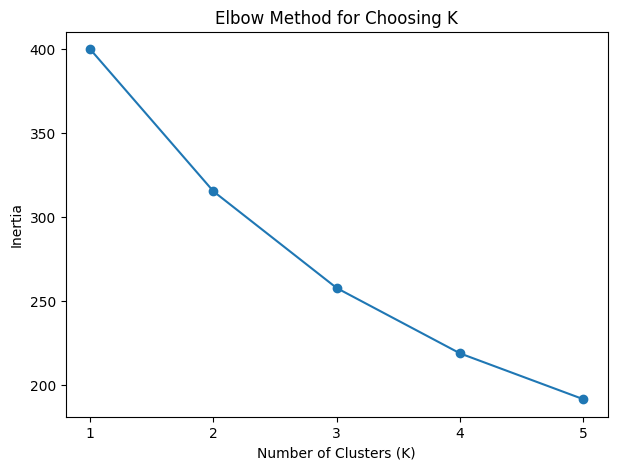

===== CUSTOMER SEGMENTS =====
         annual_spending  purchase_frequency    age  region
cluster                                                    
0             5686212.88               34.31  30.08    8.12
1             2744767.79               59.78  47.70    4.97
2             7514796.71               37.76  50.79    4.18

===== CUSTOMERS PER CLUSTER =====
cluster
0    26
1    40
2    34
Name: count, dtype: int64

===== MARKETING STRATEGIES =====
Cluster 0: High-spending customers: Offer premium products and exclusive deals.
Cluster 1: Frequent buyers: Offer loyalty rewards and repeat-purchase discounts.
Cluster 2: High-spending customers: Offer premium products and exclusive deals.

Cluster assignments saved to:
/content/customer_segments.csv


In [2]:
# Part 3: Customer Segmentation using K-Means

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the dataset
df = pd.read_csv("/content/paris_housing.csv")

# Use 100 records
df = df.head(100).copy()

# Create realistic customer ages (18-70)
# Using a fixed random seed makes the results reproducible
import numpy as np
np.random.seed(42)

df["age"] = np.random.randint(18, 71, size=len(df))

# Create customer-style features
X = df[
    ["price", "numberOfRooms", "age", "cityPartRange"]
].copy()

X.columns = [
    "annual_spending",
    "purchase_frequency",
    "age",
    "region"
]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# Elbow Method
# --------------------------------------------

inertia = []

for k in range(1, 6):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 6), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.xticks(range(1, 6))
plt.show()

# --------------------------------------------
# Apply K-Means with K = 3
# --------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

X["cluster"] = kmeans.fit_predict(X_scaled)

# --------------------------------------------
# Analyze clusters
# --------------------------------------------

cluster_summary = X.groupby("cluster").mean()

print("===== CUSTOMER SEGMENTS =====")
print(cluster_summary.round(2))

print("\n===== CUSTOMERS PER CLUSTER =====")
print(X["cluster"].value_counts().sort_index())

# --------------------------------------------
# Marketing strategies
# --------------------------------------------

print("\n===== MARKETING STRATEGIES =====")

avg_spending = X["annual_spending"].mean()
avg_frequency = X["purchase_frequency"].mean()

for cluster in cluster_summary.index:

    spending = cluster_summary.loc[cluster, "annual_spending"]
    frequency = cluster_summary.loc[cluster, "purchase_frequency"]

    if spending > avg_spending and frequency > avg_frequency:
        strategy = "High-value customers: Offer exclusive promotions and loyalty rewards."

    elif frequency > avg_frequency:
        strategy = "Frequent buyers: Offer loyalty rewards and repeat-purchase discounts."

    elif spending > avg_spending:
        strategy = "High-spending customers: Offer premium products and exclusive deals."

    else:
        strategy = "Lower-value customers: Offer introductory discounts and personalized offers."

    print(f"Cluster {cluster}: {strategy}")

# --------------------------------------------
# Save results
# --------------------------------------------

df["cluster"] = X["cluster"]

df.to_csv(
    "/content/customer_segments.csv",
    index=False
)

print("\nCluster assignments saved to:")
print("/content/customer_segments.csv")